**Import packages and libraries**

In [1]:
!pip uninstall -y numpy pandas

Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4


In [3]:
!pip install "pandas==2.2.2"
!pip install "numpy==1.26.4"

In [4]:
!pip install gensim
!pip install scikit-learn matplotlib
!pip install transformers torch
!pip install datasets
!pip install -U sentence-transformers
!pip install -U accelerate
!pip install plotly
!pip install vaderSentiment accelerate
!pip install sentence-transformers
!pip install xgboost

In [16]:
# import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
import pandas as pd
import numpy as np
import json
import re

import nltk
from nltk.sentiment import SentimentIntensityAnalyzer
nltk.download('vader_lexicon')

import networkx as nx
from networkx.algorithms import community
import seaborn as sns
from scipy import stats
import matplotlib.pyplot as plt

from collections import Counter
from imblearn.over_sampling import RandomOverSampler
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from sentence_transformers import SentenceTransformer

from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, f1_score, cohen_kappa_score, accuracy_score
from sklearn.utils import resample
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

import xgboost as xgb

RecursionError: maximum recursion depth exceeded

**Import the git files**

In [15]:
import sys
sys.setrecursionlimit(5000)  # Increase recursion limit


In [4]:
!git clone https://github.com/coralie-sorbet/project_web_mining.git

Cloning into 'project_web_mining'...
remote: Enumerating objects: 185, done.
remote: Counting objects: 100% (30/30), done.
remote: Compressing objects: 100% (23/23), done.
remote: Total 185 (delta 16), reused 18 (delta 7), pack-reused 155 (from 1)
Receiving objects: 100% (185/185), 27.31 MiB | 12.58 MiB/s, done.
Resolving deltas: 100% (103/103), done.
Updating files: 100% (30/30), done.


In [7]:
path_data = '/content/project_web_mining/database/Everything/database_formated_for_NetworkX.graphml'

graph = nx.read_graphml(path_data)

**Extract types of nodes and priorities**

In [8]:
# Extract different kinds of nodes
unique_labels = set(data.get("labels") for _, data in graph.nodes(data=True))

print("Distincts types of nodes using 'labels' attribut:", unique_labels)

Distincts types of nodes using 'labels' attribut: {':Event', ':User', ':Tweet', ':Hashtag', ':PostCategory'}


**Priority Types**

In [9]:
# We want to see the different types of priority values of a tweet
priority_types = set(data.get("annotation_postPriority") for _, data in graph.nodes(data=True) if data.get("labels") == ":Tweet")

print(f"Number of unique values for 'annotation_postPriority': {len(priority_types)}")
print(f"Unique values of 'annotation_postPriority': {priority_types}")

Number of unique values for 'annotation_postPriority': 5
Unique values of 'annotation_postPriority': {'High', 'Medium', 'Unknown', 'Low', 'Critical'}


In [10]:
# We want to see the distribution of the priority values
tweet_priorities = [data['annotation_postPriority'] for _, data in graph.nodes(data=True) if data.get('labels') == ":Tweet"]

# Count occurrences of each annotation_postPriority
priority_counts = Counter(tweet_priorities)

# Display the counts
print(priority_counts)

NameError: name 'Counter' is not defined

In [11]:
# We are only interested in the Low, Medium and High categories, so we can get rid of the Unknown and Critical ones
nodes_to_remove = [
    node for node, data in graph.nodes(data=True)
    if data.get('labels') == ":Tweet" and data.get('annotation_postPriority') in ["Unknown", "Critical"]
]
graph.remove_nodes_from(nodes_to_remove)

In [12]:
num_nodes = graph.number_of_nodes()
print(num_nodes)

89832


Get a random sample of 10,000 nodes to speed up analysis.

In [13]:
import random

random.seed(42)

# Get all nodes from the graph
all_nodes = list(graph.nodes())

# Select a random sample of 50,000 nodes (or all if fewer than 10,000 exist)
subset_size = min(20000, len(all_nodes))  # Avoid errors if graph has fewer nodes
random_nodes = random.sample(all_nodes, subset_size)

# Create a subgraph with only the selected nodes
graph = graph.subgraph(random_nodes).copy()


**Feature extraction and creation**

In [18]:
# Link tweets to user information
# Initialize lists to store data
tweet_ids = []
user_ids = []
user_names = []
followers_counts = []
listed = []
statuses = []
friends = []
verified = []
favourites = []
priorities = []
texts = []
favs = []
sens = []
annots = []
retweets = []
dates = []
screens = []

# Iterate over edges to extract information from "POSTED" relationships
for u, v, edge_data in graph.edges(data=True):
    if edge_data.get("label") == "POSTED":
        tweet_id = graph.nodes[v].get("id_str")  # Tweet ID
        user_id = graph.nodes[u].get("id")  # User ID
        user_name = graph.nodes[u].get("name")  # User name
        user_favourites = graph.nodes[u].get("favourites_count", 0)
        user_listed = graph.nodes[u].get("listed_count", 0)
        user_friends = graph.nodes[u].get("friends_count", 0)
        user_statuses = graph.nodes[u].get("statuses_count", 0)
        user_verified = graph.nodes[u].get("isVerified")
        followers_count = graph.nodes[u].get("followers_count", 0)
        priority = graph.nodes[v].get("annotation_postPriority")
        screen_name = graph.nodes[u].get("screen_name")
        text = graph.nodes[v].get("text", "")
        sensitive = graph.nodes[v].get("possibly_sensitive")
        retweet = graph.nodes[v].get("retweet_count")
        fav = graph.nodes[v].get("favourite_count")
        annot = graph.nodes[v].get("annotation_num_judgements")
        date = graph.nodes[v].get("created_at")

        # Append data to lists
        tweet_ids.append(tweet_id)
        user_ids.append(user_id)
        user_names.append(user_name)
        followers_counts.append(followers_count)
        listed.append(user_listed)
        statuses.append(user_statuses)
        friends.append(user_friends)
        verified.append(user_verified)
        favourites.append(user_favourites)
        priorities.append(priority)
        texts.append(text)
        annots.append(annot)
        sens.append(sensitive)
        favs.append(fav)
        retweets.append(retweet)
        dates.append(date)
        screens.append(screen_name)

# Convert lists to DataFrame
df_tweets = pd.DataFrame({
    "tweet_id": tweet_ids,
    "user_id": user_ids,
    "user_name": user_names,
    "screen_name": screens,
    "listed_count": listed,
    "statuses_count": statuses,
    "friends_count": friends,
    "isVerified": verified,
    "favourites_count": favourites,
    "followers_count": followers_counts,
    "annotation_postPriority": priorities,
    "text": texts,
    "annotation_num_judgements": annot,
    "possibly_sensitive": sens,
    "retweet_count": retweet,
    "created_at": dates
})

# Link tweets to hashtags
tweet_ids_ht = []
hashtags_list = []
hashtags_count_list = []

for u, v, edge_data in graph.edges(data=True):
    if edge_data.get("label") == "HAS_HASHTAG":
        tweet_id = graph.nodes[u].get("id_str")
        hashtag = graph.nodes[v].get("id")
        hashtag_count = graph.nodes[v].get("occurences", 0)

        tweet_ids_ht.append(tweet_id)
        hashtags_list.append(hashtag)
        hashtags_count_list.append(hashtag_count)

# Create DataFrame for hashtags
df_hashtags = pd.DataFrame({
    "tweet_id": tweet_ids_ht,
    "hashtag": hashtags_list,
    "hashtag_count": hashtags_count_list
})

# Link tweets to events
tweet_ids_event = []
event_type = []
event_ids = []

for u, v, edge_data in graph.edges(data=True):
    if edge_data.get("label") == "IS_ABOUT":
        tweet_id_event = graph.nodes[u].get("id_str")
        event_id = graph.nodes[v].get("id")
        event = graph.nodes[v].get("eventType")

        tweet_ids_event.append(tweet_id_event)
        event_ids.append(event_id)
        event_type.append(event)

df_events = pd.DataFrame({
    "tweet_id": tweet_ids_event,
    "event_id": event_ids,
    "eventType": event_type
})

# Merge tweet, event, user and hashtag data using an outer join to preserve all tweets
df_final = pd.merge(df_tweets, df_hashtags, on="tweet_id", how="outer")
df_final = pd.merge(df_final, df_events, on="tweet_id", how="outer")
print(df_final.head())

TypeError: Cannot convert numpy.ndarray to numpy.ndarray

In [ ]:
# Mentions of users in a tweet
tweet_ids = []
user_mentioned_tweet = []
user_ids = []
mention_times = []
user_mentioned = []

for u, v, edge_data in graph.edges(data=True):
    if edge_data.get("label") == "MENTIONS":
        if graph.nodes[u].get("labels") == ":Tweet":
            tweet_id = graph.nodes[u].get("id_str")
            tweet_ids.append(tweet_id)
            mentioned_user_id = graph.nodes[v].get("id")
            user_mentioned_tweet.append(mentioned_user_id)


for u, v, edge_data in graph.edges(data=True):
    if edge_data.get("label") == "MENTIONS":
        if graph.nodes[u].get("labels") == ":User":
            mentioned_user_id = graph.nodes[v].get("id")
            user_mentioned.append(mentioned_user_id)
            user_id = graph.nodes[u].get("id")
            mention_time = edge_data.get("times")
            user_ids.append(user_id)
            mention_times.append(mention_time)

# Create DataFrame
df_mentions_tweet = pd.DataFrame({
    "tweet_id": tweet_ids,
    "mentioned_user": user_mentioned_tweet
})

df_mentions_user = pd.DataFrame({
    "user_id": user_ids,
    "mentioned_user": user_mentioned,
    "mention_times": mention_times
})

# Add the data on mentioned users in the tweet to our dataset
df_final = df_final.merge(df_mentions_tweet, on="tweet_id", how="outer")

In [15]:
df_final

,tweet_id,user_id,user_name,screen_name,listed_count,statuses_count,friends_count,isVerified,favourites_count,followers_count,...,text,annotation_num_judgements,possibly_sensitive,retweet_count,created_at,hashtag,hashtag_count,event_id,eventType,mentioned_user
0,1099766204045185024,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1039616106363805697
1,1100127176198840322,23880502,Visit Pagosa,visitpagosa,64.0,5612.0,391.0,False,537.0,1627.0,...,Who remembers our friendly San Juan River Walk...,1.0,False,0.0,2019-02-25T00:00Z,NaN,NaN,NaN,NaN,NaN
2,1100242734185558016,1077644610053107712,Ronja Pia,ronjapia1,1.0,20.0,47.0,False,37.0,30.0,...,i was the ocean\n you wanted rivers\ni was the...,1.0,False,0.0,2019-02-26T00:00Z,NaN,NaN,NaN,NaN,NaN
3,1100299990323417089,1721738612,Simon Hoyte,SimonHoyte,29.0,1422.0,968.0,False,225.0,620.0,...,British oil company @AmerisurResourc has been ...,1.0,False,0.0,2019-02-26T00:00Z,NaN,NaN,NaN,NaN,NaN
4,1100527901550825474,1073885061508927488,SEASONAL MAFIA,Victorina____,0.0,406.0,65.0,False,449.0,61.0,...,"RT @UNDP: In 2010, flood water saturated w/ me...",1.0,True,0.0,2019-02-26T00:00Z,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
118067,None,531558229,Audrey Washington,AudreyWSBTV,175.0,24035.0,2021.0,True,27790.0,6015.0,...,A Tennessee couple is opening their home to wh...,1.0,False,0.0,2018-09-14T00:00Z,foodstagram,1.0,NaN,NaN,309089215
118068,None,531558229,Audrey Washington,AudreyWSBTV,175.0,24035.0,2021.0,True,27790.0,6015.0,...,A Tennessee couple is opening their home to wh...,1.0,False,0.0,2018-09-14T00:00Z,foodstagram,1.0,NaN,NaN,299798272
118069,None,531558229,Audrey Washington,AudreyWSBTV,175.0,24035.0,2021.0,True,27790.0,6015.0,...,A Tennessee couple is opening their home to wh...,1.0,False,0.0,2018-09-14T00:00Z,foodstagram,1.0,NaN,NaN,2097571
118070,None,531558229,Audrey Washington,AudreyWSBTV,175.0,24035.0,2021.0,True,27790.0,6015.0,...,A Tennessee couple is opening their home to wh...,1.0,False,0.0,2018-09-14T00:00Z,foodstagram,1.0,NaN,NaN,15080288


In [ ]:
df_final = df_final.drop_duplicates()

In [ ]:
df_final.isin(["", None, np.nan]).sum()

In [18]:
# We make sure the user ids are strings
#df_mentions_user["user_id"] = df_mentions_user["user_id"].astype("string")
#df_mentions_user["mentioned_user"] = df_mentions_user["mentioned_user"].astype("string")
#df_final["user_id"] = df_final["user_id"].astype("string")

# Make sure the mention time is numeric
df_mentions_user.loc[:, "mention_times"] = pd.to_numeric(df_mentions_user["mention_times"], errors="coerce").astype("Int64")

# How many users someone mentions to identify users who interact with many different people
df_user_mentions_count = df_mentions_user.groupby("user_id")["mentioned_user"].nunique().reset_index()
df_user_mentions_count.rename(columns={"mentioned_user": "number_users_mentioned"}, inplace=True)

# Total mentions recieved: How often a user is mentioned
df_mentions_received = df_mentions_user.groupby("mentioned_user")["mention_times"].sum().reset_index()
df_mentions_received.rename(columns={"mention_times": "total_mentions_received"}, inplace=True)
df_mentions_received.rename(columns={"mentioned_user": "user_id"}, inplace=True)

# Mentions given vs recieved ratio
# > 1 : user mentions a lot of people but isn't mentioned much (marketer)
# < 1 : user is mentioned often but doesn't engage much (influencer)
df_mentions_given = df_mentions_user.groupby("user_id")["mention_times"].sum().reset_index()
df_mentions_given.rename(columns={"mention_times": "total_mentions_given"}, inplace=True)

df_mention_ratio = df_mentions_given.merge(df_mentions_received, on="user_id", how="outer").fillna(0)
df_mention_ratio["mention_ratio"] = df_mention_ratio["total_mentions_given"] / (df_mention_ratio["total_mentions_received"] + 1)
df_mention_ratio = df_mention_ratio[["user_id", "mention_ratio"]]

# Mutual mentions : high score = strong connections
df_reciprocal_mentions = df_mentions_user.merge(df_mentions_user, left_on=["user_id", "mentioned_user"], right_on=["mentioned_user", "user_id"])
df_reciprocal_mentions["reciprocity_score"] = df_reciprocal_mentions["mention_times_x"] + df_reciprocal_mentions["mention_times_y"]
df_reciprocal_mentions.rename(columns={"user_id_x": "user_id"}, inplace=True)
df_reciprocal_mentions = df_reciprocal_mentions[["user_id", "reciprocity_score"]]

# Merge all the data together
df_user_mentions_count = df_user_mentions_count.merge(df_mentions_received, on="user_id", how="outer").fillna(0)
df_user_mentions_count = df_user_mentions_count.merge(df_mentions_given, on="user_id", how="outer").fillna(0)
df_user_mentions_count = df_user_mentions_count.merge(df_mention_ratio, on="user_id", how="outer").fillna(0)
df_user_mentions_count = df_user_mentions_count.merge(df_reciprocal_mentions, on="user_id", how="outer").fillna(0)

df_final = pd.merge(df_final, df_user_mentions_count, on="user_id", how="outer")
#df_final = df_final.merge(df_user_mentions_count, on="user_id", how="outer")

In [19]:
df_final = df_final.dropna(subset = ['text', 'annotation_postPriority'])

In [20]:
df_final.isin(["", None, np.nan]).sum()

,0
tweet_id,34680
user_id,0
user_name,0
screen_name,0
listed_count,0
statuses_count,0
friends_count,0
isVerified,0
favourites_count,0
followers_count,0


In [21]:
df_final['hashtag'] = df_final['hashtag'].fillna('None')
df_final['hashtag_count'] = df_final['hashtag_count'].fillna(0)

In [22]:
df_final[['number_users_mentioned', 'total_mentions_received',
          'total_mentions_given', 'mention_ratio', 'reciprocity_score']] = \
df_final[['number_users_mentioned', 'total_mentions_received',
          'total_mentions_given', 'mention_ratio', 'reciprocity_score']].fillna(0)


In [23]:
df_final['eventType'] = df_final['eventType'].fillna('Unrelated')
df_final['event_id'] = df_final['event_id'].fillna('Unrelated')

In [24]:
df_final['mentioned_user'] = df_final['mentioned_user'].fillna('No Mentions')

In [25]:
df_final = df_final[df_final['user_name'] != ""]

In [26]:
df_final.isin(["", None, np.nan]).sum()

,0
tweet_id,34680
user_id,0
user_name,0
screen_name,0
listed_count,0
statuses_count,0
friends_count,0
isVerified,0
favourites_count,0
followers_count,0


In [27]:
df_final = df_final.drop(columns= ['tweet_id'] )

In [28]:
# Create the column has_emoji

# Emoji pattern (covers most emojis)
emoji_pattern = re.compile("["
    "\U0001F600-\U0001F64F"  # Emoticons
    "\U0001F300-\U0001F5FF"  # Symbols & pictographs
    "\U0001F680-\U0001F6FF"  # Transport & map symbols
    "\U0001F700-\U0001F77F"  # Alchemical symbols
    "\U0001F780-\U0001F7FF"  # Geometric shapes
    "\U0001F800-\U0001F8FF"  # Supplemental arrows
    "\U0001F900-\U0001F9FF"  # Supplemental symbols and pictographs
    "\U0001FA00-\U0001FA6F"  # Chess symbols, etc.
    "\U0001FA70-\U0001FAFF"  # More symbols
    "\U00002702-\U000027B0"  # Dingbats
    "\U000024C2-\U0001F251"
"]+", flags=re.UNICODE)

# Function to extract emojis from text
def extract_emojis(text):
    return emoji_pattern.findall(text) if isinstance(text, str) else []

# Apply functions to create new columns
df_final['has_emoji'] = df_final['text'].apply(lambda x: bool(emoji_pattern.search(str(x))))
df_final['emoji_count'] = df_final['text'].apply(lambda x: len(extract_emojis(str(x))))

In [29]:
# We want to detect opinianated words. We will use VADER Scores
# VADER gives four sentiment scores:
# pos (0 to 1), neg (0 to 1), neu (0 to 1), compound (-1 to 1)
# If compound > 0.05 :positive, if compound < -0.05 negative, if -0.05 < compound < 0.05 neutral

# Create a column that says True if opinianated words are used in the tweet

# Initialize the Sentiment Analyzer
sia = SentimentIntensityAnalyzer()

# Function to classify sentiment
def classify_sentiment(text):
    score = sia.polarity_scores(text)['compound']
    if score >= 0.05:
        return "Positive"
    elif score <= -0.05:
        return "Negative"
    else:
        return "Neutral"

df_final['opinion'] = df_final['text'].apply(classify_sentiment)

In [30]:
import nltk
import gensim.downloader as api
from nltk.tokenize import word_tokenize

def get_word_embeddings():
  # Download and load a pre-trained Word2Vec model
  nltk.download('punkt_tab')
  model = api.load("word2vec-google-news-300")
  return model

def get_tweet_word_embedding(doc, model):
    def preprocess_text(text):
      return word_tokenize(text.lower())

    words = preprocess_text(doc)
    word_vectors = []
    for word in words:
        if word in model:
            word_vectors.append(model[word])

    if len(word_vectors) == 0:
        return np.zeros(model.vector_size)

    document_embedding = np.mean(word_vectors, axis=0)
    return document_embedding
w2v_model = get_word_embeddings()

tweet_embeddings = []  # Store embeddings
texts = df_final["text"]
for tweet_text in texts:
    tweet_vector = get_tweet_word_embedding(tweet_text, w2v_model)
    tweet_embeddings.append(tweet_vector)

df_final["tweet_embedding"] = tweet_embeddings

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


[==================================================] 100.0% 1662.8/1662.8MB downloaded


In [31]:
user_embeddings = []
usernames = df_final["user_name"]

for username in usernames:
    user_vector = get_tweet_word_embedding(username, w2v_model)
    user_embeddings.append(user_vector)

df_final["user_embeddings"] = user_embeddings

**Preparing the model**

In [32]:
X = df_final.drop('annotation_postPriority', axis=1)  # Features
y = df_final['annotation_postPriority']  # Target: the priority classes

# Initialize Stratified Shuffle Split (to maintain the class distribution in both train and test)
splitter = StratifiedShuffleSplit(n_splits=1, test_size=0.3, random_state=42)

# Split data
for train_index, test_index in splitter.split(X, y):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

# Combine features and target into a train/test dataset
train_data = X_train.copy()
train_data['annotation_postPriority'] = y_train

test_data = X_test.copy()
test_data['annotation_postPriority'] = y_test


In [33]:
# Check class distribution in the training and test sets
print("Training Set Class Distribution:")
print(train_data['annotation_postPriority'].value_counts())

print("\nTest Set Class Distribution:")
print(test_data['annotation_postPriority'].value_counts())


Training Set Class Distribution:
annotation_postPriority
Low       20273
Medium     3946
High       1289
Name: count, dtype: int64

Test Set Class Distribution:
annotation_postPriority
Low       8688
Medium    1692
High       552
Name: count, dtype: int64


In [34]:
# Separate the majority and minority classes in the training data
majority_class = train_data[train_data['annotation_postPriority'] == 'Low']  # Replace with your exact class names
minority_class = train_data[train_data['annotation_postPriority'] != 'Low']

# Oversample the minority class
minority_upsampled = resample(minority_class,
                               replace=True,
                               n_samples=len(majority_class),  # Match the size of the majority class
                               random_state=42)

# Combine majority class with oversampled minority class
train_balanced = pd.concat([majority_class, minority_upsampled])

# Shuffle the training data to ensure randomness
train_balanced = train_balanced.sample(frac=1, random_state=42).reset_index(drop=True)


In [35]:
# Check class distribution in the training and test sets
print("Training Set Class Distribution:")
print(train_balanced['annotation_postPriority'].value_counts())

print("\nTest Set Class Distribution:")
print(test_data['annotation_postPriority'].value_counts())


Training Set Class Distribution:
annotation_postPriority
Low       20273
Medium    15290
High       4983
Name: count, dtype: int64

Test Set Class Distribution:
annotation_postPriority
Low       8688
Medium    1692
High       552
Name: count, dtype: int64


In [36]:
# Drop non-numeric columns
X_train_numeric = X_train.select_dtypes(exclude=['object'])
X_test_numeric = X_test.select_dtypes(exclude=['object'])

# Scale the numeric features using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_numeric)  # Fit and transform on train data
X_test_scaled = scaler.transform(X_test_numeric)  # Transform on test data


# Apply TF-IDF on the 'text' column
tfidf_vectorizer = TfidfVectorizer(max_features=5000)
X_train_text = tfidf_vectorizer.fit_transform(X_train['text']).toarray()
X_test_text = tfidf_vectorizer.transform(X_test['text']).toarray()

# Now 'text' is numerically represented, we can concatenate it with the rest
X_train_final = np.concatenate([X_train_scaled, X_train_text], axis=1)
X_test_final = np.concatenate([X_test_scaled, X_test_text], axis=1)


**Prediction Models**

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# Define the parameter grid
param_grid = {
    'n_estimators': [50, 100, 200],  # Number of trees
    'max_depth': [None, 10, 20],  # Maximum depth of trees
    'min_samples_split': [2, 5, 10],  # Minimum samples to split a node
    'min_samples_leaf': [1, 2, 4],  # Minimum samples per leaf
    'criterion': ['gini', 'entropy']  # Splitting criteria
}

# Initialize the model
rf = RandomForestClassifier(random_state=42)

# Perform Grid Search
grid_search = GridSearchCV(rf, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
grid_search.fit(X_train_final, y_train)

# Best parameters and best model
print("Best Parameters:", grid_search.best_params_)
print("Best Accuracy:", grid_search.best_score_)

# Train the best model on the full dataset
best_rf = grid_search.best_estimator_


Fitting 5 folds for each of 162 candidates, totalling 810 fits


In [ ]:
# RandomForestClassifier
model = RandomForestClassifier(
    criterion='gini',
    max_depth=None,
    min_samples_leaf=1,
    min_samples_split=2,
    n_estimators=100,
    random_state=42
)

model.fit(X_train_final, y_train)

y_pred = model.predict(X_test_final)

print("Accuracy on Test Data:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy on Test Data: 0.9450757575757576

Classification Report:
               precision    recall  f1-score   support

        High       1.00      0.14      0.25        14
         Low       0.94      1.00      0.97       425
      Medium       1.00      0.81      0.89        89

    accuracy                           0.95       528
   macro avg       0.98      0.65      0.70       528
weighted avg       0.95      0.95      0.94       528



In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

# Define the parameter grid
param_grid = {
    'penalty': ['l1', 'l2', 'elasticnet', None],  # Regularization type
    'C': [0.001, 0.01, 0.1, 1, 10, 100],  # Regularization strength
    'solver': ['liblinear', 'lbfgs', 'saga'],  # Optimization solvers
}

# Initialize Logistic Regression
log_reg = LogisticRegression(max_iter=1000, random_state=42)

# Grid Search
grid_search = GridSearchCV(log_reg, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
grid_search.fit(X_train_final, y_train)

# Best parameters
print("Best Parameters:", grid_search.best_params_)
print("Best Accuracy:", grid_search.best_score_)

# Train the best model
best_log_reg = grid_search.best_estimator_


Fitting 5 folds for each of 72 candidates, totalling 360 fits


KeyboardInterrupt: 

In [ ]:
# Logistic Regression
log_reg = LogisticRegression(max_iter=1000, random_state=42)

log_reg.fit(X_train_final, y_train)

y_pred_log = log_reg.predict(X_test_final)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))
print("\nClassification Report:\n", classification_report(y_test, y_pred_log))


Logistic Regression Accuracy: 0.9261363636363636

Classification Report:
               precision    recall  f1-score   support

        High       0.50      0.07      0.12        14
         Low       0.93      0.99      0.96       425
      Medium       0.92      0.78      0.84        89

    accuracy                           0.93       528
   macro avg       0.78      0.61      0.64       528
weighted avg       0.92      0.93      0.92       528



In [ ]:
# SVM with RBF Kernel
svm_model = SVC(kernel='rbf', C=1.0, random_state=42)

svm_model.fit(X_train_final, y_train)

y_pred_svm = svm_model.predict(X_test_final)

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print("\nClassification Report:\n", classification_report(y_test, y_pred_svm))

SVM Accuracy: 0.9318181818181818

Classification Report:
               precision    recall  f1-score   support

        High       0.00      0.00      0.00        14
         Low       0.92      1.00      0.96       425
      Medium       0.99      0.76      0.86        89

    accuracy                           0.93       528
   macro avg       0.64      0.59      0.61       528
weighted avg       0.91      0.93      0.92       528



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.6/383.6 kB 23.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.8/231.8 kB 17.9 MB/s eta 0:00:00


In [ ]:
import optuna
from sklearn.model_selection import cross_val_score

# Define objective function for optimization
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'gamma': trial.suggest_float('gamma', 0, 0.5),
        'random_state': 42,
        'use_label_encoder': False,
        'eval_metric': "logloss"
    }

    model = xgb.XGBClassifier(**params)
    scores = cross_val_score(model, X_train_final, y_train_encoded, cv=5, scoring='accuracy')
    return scores.mean()  # Maximize accuracy

# Run optimization
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30)  # Adjust trials for better results

# Print best parameters
print("Best Parameters:", study.best_params)

# Train final model with best parameters
best_xgb = xgb.XGBClassifier(**study.best_params)
best_xgb.fit(X_train_final, y_train_encoded)

# Make predictions
y_pred_optuna = best_xgb.predict(X_test_final)

# Evaluate performance
print("Optimized XGBoost Accuracy:", accuracy_score(y_test_encoded, y_pred_optuna))



[I 2025-03-26 11:50:51,396] A new study created in memory with name: no-name-a75f09cc-1362-4d7a-bc2b-fd199448e5f3
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [11:50:51] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [11:50:55] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [11:51:05] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [11:51:17] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-package

KeyboardInterrupt: 

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Initialize label encoder
label_encoder = LabelEncoder()
# XGBoost Classifier
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)  # Use transform only (not fit) for test set

xgb_model = xgb.XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42, use_label_encoder=False, eval_metric="logloss")

xgb_model.fit(X_train_final, y_train_encoded)

y_pred_xgb = xgb_model.predict(X_test_final)

print("XGBoost Accuracy:", accuracy_score(y_test_encoded, y_pred_xgb))
print("\nClassification Report:\n", classification_report(y_test_encoded, y_pred_xgb))


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [11:13:43] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBoost Accuracy: 0.9128787878787878

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.14      0.25        14
           1       0.94      0.96      0.95       425
           2       0.80      0.82      0.81        89

    accuracy                           0.91       528
   macro avg       0.91      0.64      0.67       528
weighted avg       0.91      0.91      0.91       528



In [ ]:
# Store all metrics in a DataFrame
metrics_results = pd.DataFrame({
    "Model": ["Random Forest", "Logistic Regression", "SVM (RBF)", "XGBoost"],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_svm),
        accuracy_score(y_test_encoded, y_pred_xgb)
    ],
    "Precision": [
        precision_score(y_test, y_pred, average="weighted"),
        precision_score(y_test, y_pred_log, average="weighted"),
        precision_score(y_test, y_pred_svm, average="weighted"),
        precision_score(y_test_encoded, y_pred_xgb, average="weighted")
    ],
    "Recall": [
        recall_score(y_test, y_pred, average="weighted"),
        recall_score(y_test, y_pred_log, average="weighted"),
        recall_score(y_test, y_pred_svm, average="weighted"),
        recall_score(y_test_encoded, y_pred_xgb, average="weighted")
    ],
    "F1-Score": [
        f1_score(y_test, y_pred, average="weighted"),
        f1_score(y_test, y_pred_log, average="weighted"),
        f1_score(y_test, y_pred_svm, average="weighted"),
        f1_score(y_test_encoded, y_pred_xgb, average="weighted")
    ]
})

# Display the table
print(metrics_results)


                 Model  Accuracy  Precision    Recall  F1-Score
0        Random Forest  0.945076   0.948584  0.945076  0.935759
1  Logistic Regression  0.926136   0.916145  0.926136  0.915159
2            SVM (RBF)  0.931818   0.909664  0.931818  0.917235
3              XGBoost  0.912879   0.914847  0.912879  0.905220


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


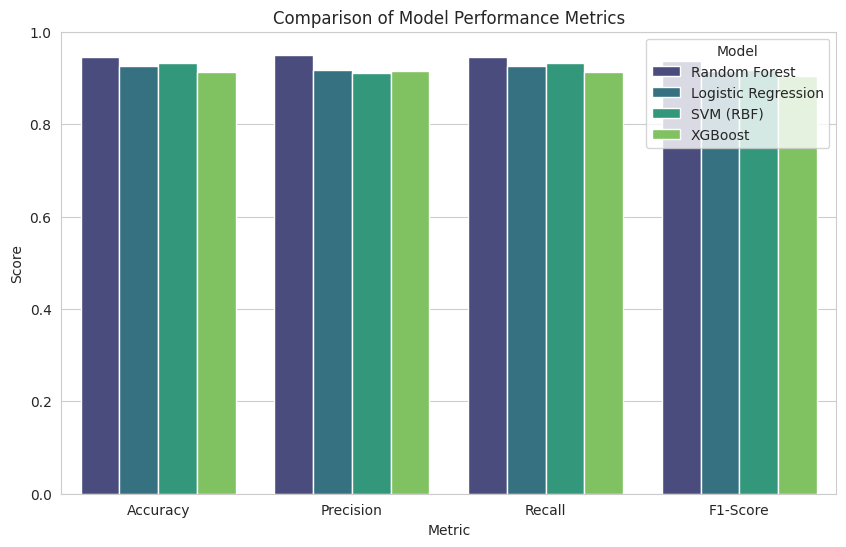

In [ ]:
# Set plot style
plt.figure(figsize=(10,6))
sns.set_style("whitegrid")

# Convert dataframe to long format for easy plotting
metrics_melted = metrics_results.melt(id_vars="Model", var_name="Metric", value_name="Score")

# Plot grouped bar chart
sns.barplot(x="Metric", y="Score", hue="Model", data=metrics_melted, palette="viridis")

# Formatting
plt.title("Comparison of Model Performance Metrics")
plt.ylim(0, 1)
plt.ylabel("Score")
plt.xlabel("Metric")
plt.legend(title="Model")
plt.show()
